In [2]:
import tensorflow as tf
import numpy as np
from keras.datasets import imdb
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.models import Sequential
from keras.preprocessing.sequence import pad_sequences

In [3]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [4]:
maxlen = 200
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

In [5]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, maxlen))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 138ms/step - accuracy: 0.7038 - loss: 0.5401 - val_accuracy: 0.8644 - val_loss: 0.3362
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.9030 - loss: 0.2581 - val_accuracy: 0.8592 - val_loss: 0.3254
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.9297 - loss: 0.1884 - val_accuracy: 0.8534 - val_loss: 0.3734
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.9486 - loss: 0.1378 - val_accuracy: 0.8522 - val_loss: 0.3989
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9651 - loss: 0.1025 - val_accuracy: 0.8610 - val_loss: 0.4360


In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8536 - loss: 0.4535
Test Accuracy: 0.8542


In [8]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in encoded_review])

In [11]:
index = 54

print(decode_review(X_test[index]))
pred = model.predict(X_test[index:index+1])[0][0]
print("Sentiment: ", "Positive" if pred > 0.5 else "Negative")

? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? it plays like your usual teenage audience t a movie but the sentiment is incredibly bleak if it was made today it'd be considered an art house movie it goes through the usual routine of a guy trying to get laid but the results of his efforts are harsh and cruel and unsatisfying br br the whole teen flick formula is ? to but nothing turns out the way you'd expect imagine a director's cut of ? a wonderful ? where at the end james stewart wasn't allowed to return to the real world an incredible film that ? all of the expectations of the genre it makes you feel dirty afterwards there is no redemption for the characters i'm amazed it ever got made the eighties version of detective story
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Sentiment:  Positive


782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step


C:\Users\Om Shete\AppData\Local\Temp\ipykernel_20752\2275834390.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sentiment_counts.keys()), y=list(sentiment_counts.values()), palette='coolwarm')


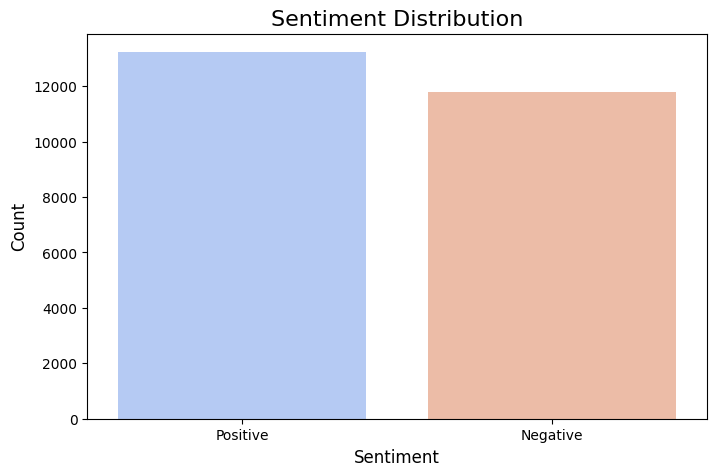

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get sentiment predictions for all reviews
predictions = model.predict(X_test)
sentiments = ["Positive" if pred > 0.5 else "Negative" for pred in predictions[:, 0]]

# Count occurrences of each sentiment
sentiment_counts = {
    "Positive": sentiments.count("Positive"),
    "Negative": sentiments.count("Negative")
}

# Create bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=list(sentiment_counts.keys()), y=list(sentiment_counts.values()), palette='coolwarm')
plt.title('Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
